## 产物一致性比较

In [8]:
import numpy as np

# 加载保存好的测试集
X_pill = np.load('./pillow/output/X_test_pill.npy')
X_ski = np.load('./skimage/output/X_test_ski.npy')

# 1. 计算均方误差 (MSE)
mse = np.mean((X_pill - X_ski) ** 2)

# 2. 计算最大像素偏差 (Max Difference)
# 因为两者都归一化到了 [0, 1]，这个差值能体现算法的波动
max_diff = np.abs(X_pill - X_ski).max()

# 3. 计算结构相似性 (简单近似)
correlation = np.corrcoef(X_pill.flatten(), X_ski.flatten())[0, 1]

print("="*35)
print("PIXEL-LEVEL COMPARISON REPORT")
print("="*35)
print(f"Mean Squared Error:   {mse:.8f}")
print(f"Max Pixel Difference: {max_diff:.4f} (scale 0-1)")
print(f"Pearson Correlation:  {correlation:.6f}")
print("="*35)

PIXEL-LEVEL COMPARISON REPORT
Mean Squared Error:   0.00005576
Max Pixel Difference: 0.1358 (scale 0-1)
Pearson Correlation:  0.999703


## 训练结果比较

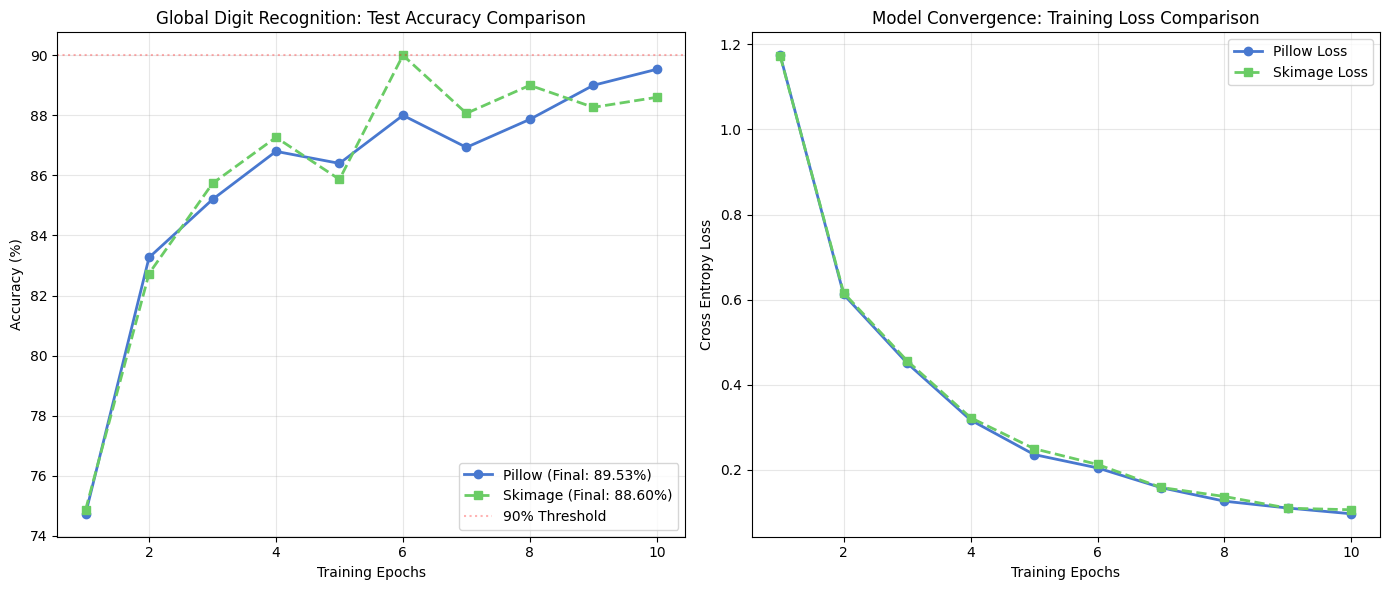

In [5]:
import matplotlib.pyplot as plt
import json
import os

# 相对路径
PILL_HISTORY = './pillow/output/history_pill.json'
SKI_HISTORY = './skimage/output/history_ski.json'
SAVE_PATH = './final_comparison.png'


with open(PILL_HISTORY, 'r') as f:
    h_pill = json.load(f)
with open(SKI_HISTORY, 'r') as f:
    h_ski = json.load(f)

# 可视化
if 'h_pill' in locals() and 'h_ski' in locals():
    epochs = range(1, 11)
    plt.figure(figsize=(14, 6))
    plt.style.use('seaborn-v0_8-muted')

    # 准确率对比曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs, h_pill['test_acc'], 'o-', linewidth=2, label=f'Pillow (Final: {h_pill["test_acc"][-1]:.2f}%)')
    plt.plot(epochs, h_ski['test_acc'], 's--', linewidth=2, label=f'Skimage (Final: {h_ski["test_acc"][-1]:.2f}%)')
    plt.axhline(y=90, color='r', linestyle=':', alpha=0.3, label='90% Threshold')
    plt.title('Global Digit Recognition: Test Accuracy Comparison', fontsize=12)
    plt.xlabel('Training Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 训练损失对比曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs, h_pill['train_loss'], 'o-', linewidth=2, label='Pillow Loss')
    plt.plot(epochs, h_ski['train_loss'], 's--', linewidth=2, label='Skimage Loss')
    plt.title('Model Convergence: Training Loss Comparison', fontsize=12)
    plt.xlabel('Training Epochs')
    plt.ylabel('Cross Entropy Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(SAVE_PATH, dpi=300)
    plt.show()